<img src="./logo_UTN.svg" align="right" width="150" />

# Informe TPLAB 2

*Alumno: Lapilli Cañedo, Mariano Adrian*

## Consigna

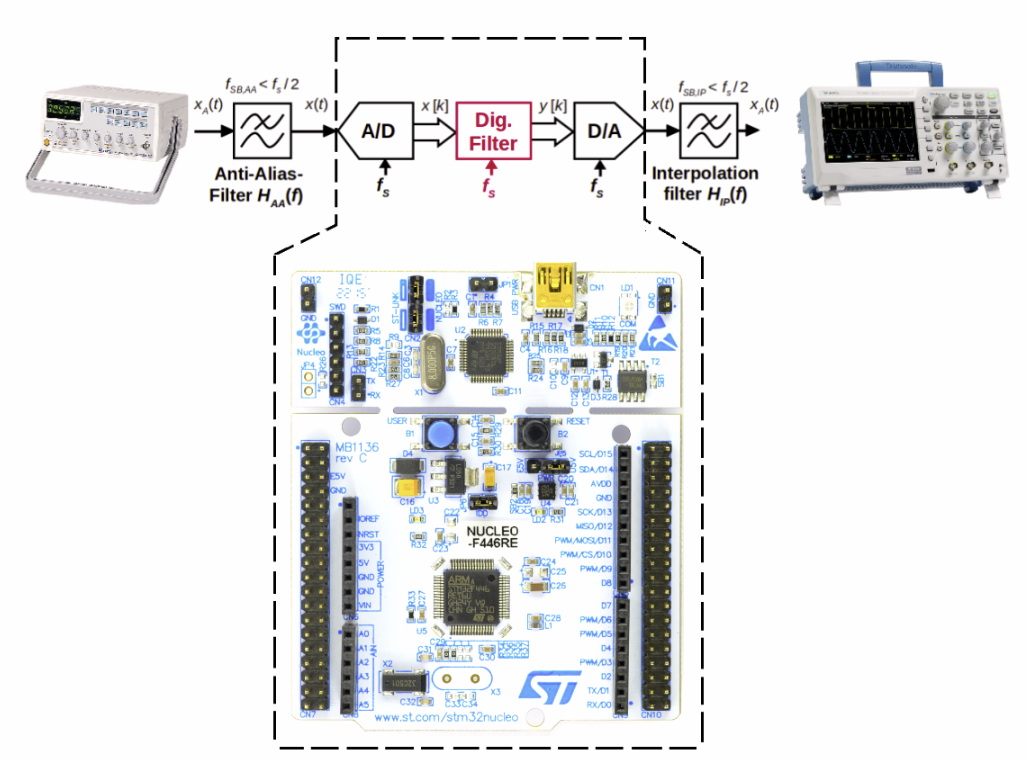

### Librería CMSIS:

El filtro digital en sí mismo es un algoritmo. En nuestro caso para simplificar la tarea vamos a instanciar funciones de la librería de procesamiento digital de arm cmis-dsp

    . arm_fir_f32 
    . arm_biquad_cascade_df1_f32

### Plantillas:

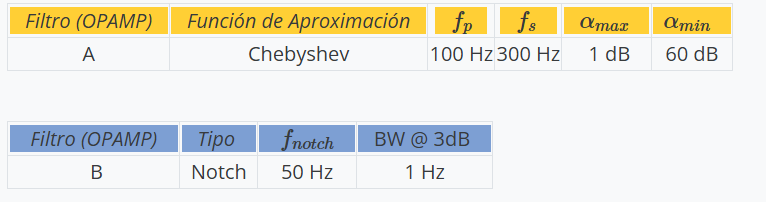


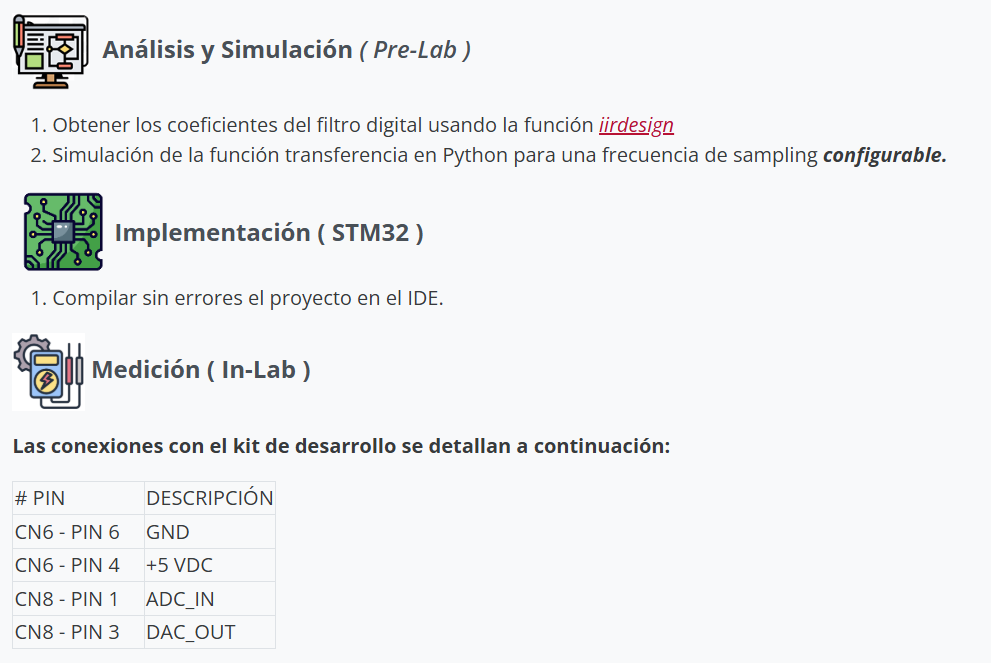

In [2]:
# Importo librerias de python para trabajar

import numpy as np
from scipy import signal as sig
import sympy as sp
import control as ct
from matplotlib import pyplot as plt
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys
from pytc2.sistemas_lineales import pretty_print_lti
from pytc2.general import print_latex, a_equal_b_latex_s
from pytc2.cuadripolos import calc_MAI_ztransf_ij_mn
from pytc2.cuadripolos import calc_MAI_vtransf_ij_mn
import sympy as sp

## Resolución

### Item 1

Me decanto por la opción A, la cual consiste en un Chebyshev, con los siguientes datos:

- $f_p = 100 Hz$
- $f_S = 300 Hz$
- $\alpha_{max} = 1 dB$
- $\alpha_{min} = 60 dB$

Haciendo uso de la función **iirdesign** de **SciPy** vamos a obtener los coeficientes:


[[ 1.836000e-03  3.671000e-03  1.836000e-03  1.000000e+00 -1.554785e+00
   6.492950e-01]
 [ 1.000000e+00  2.000000e+00  1.000000e+00  1.000000e+00 -1.499554e+00
   8.482190e-01]]


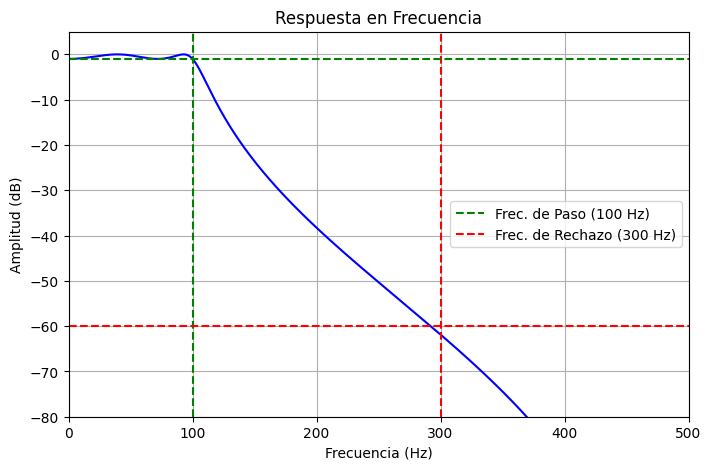

In [39]:
# Obtencion de coeficientes
fp = 100.0      
f_stop = 300.0  
gpass = 1.0     
gstop = 60.0    

fs_muestreo = 1000.0  
nyq = 0.5 * fs_muestreo 

wp = fp / nyq
ws = f_stop / nyq

sos = sig.iirdesign(wp, ws, gpass, gstop, analog=False, ftype='cheby1', output='sos')

print(np.round(sos, 6))

w, h = sig.sosfreqz(sos, worN=8000, fs=fs_muestreo)
plt.figure(figsize=(8, 5))
plt.plot(w, 20 * np.log10(np.maximum(abs(h), 1e-5)), 'b')
plt.title('Respuesta en Frecuencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud (dB)')
plt.axvline(fp, color='green', linestyle='--', label='Frec. de Paso (100 Hz)')
plt.axvline(f_stop, color='red', linestyle='--', label='Frec. de Rechazo (300 Hz)')
plt.axhline(-gpass, color='green', linestyle='--')
plt.axhline(-gstop, color='red', linestyle='--')
plt.ylim(-80, 5)
plt.xlim(0, fs_muestreo/2)
plt.legend()
plt.grid(True)
plt.show()

El código me devuelve dos secciones de segundo orden, las cuales son:


$$ H_1(z) = \frac{1.83 * 10^{-3} + 3.67 * 10^{-3} z^{-1} + 1.83 * 10^{-3} z^{-2}}{1 - 1.55 z^{-1} + 0.65 z^{-2}} $$



$$ H_2(z) = \frac{1 + 2 z^{-1} + z^{-2}}{1 - 1.5 z^{-1} + 0.84 z^{-2}} $$


Haciendo el producto de ambas obtengo:

$$ H(z) = \frac{ 0.01 z^{-1} + 0.01 z^{-2} + 0.01 z^{-3} }{1.00 - 3.05 z^{-1} + 3.83 z^{-2} - 2.29 z^{-3} + 0.55 z^{-4}} $$


// Recuerda cambiar #define FIR_TAP_NUM a 365 en filter.h
float32_t float_fir_taps[FIR_TAP_NUM] = {
    -0.000149f, -0.000025f, -0.000027f, -0.000030f, -0.000033f, -0.000036f, -0.000039f, -0.000042f, -0.000045f, -0.000048f, -0.000050f, -0.000053f, -0.000056f, -0.000058f, -0.000060f, -0.000062f, -0.000063f, -0.000064f, -0.000065f, -0.000065f, -0.000065f, -0.000064f, -0.000062f, -0.000060f, -0.000057f, -0.000053f, -0.000048f, -0.000042f, -0.000036f, -0.000028f, -0.000020f, -0.000011f, 0.000000f, 0.000012f, 0.000024f, 0.000038f, 0.000053f, 0.000069f, 0.000085f, 0.000103f, 0.000122f, 0.000142f, 0.000163f, 0.000184f, 0.000206f, 0.000229f, 0.000252f, 0.000276f, 0.000300f, 0.000324f, 0.000348f, 0.000372f, 0.000396f, 0.000419f, 0.000442f, 0.000464f, 0.000484f, 0.000504f, 0.000522f, 0.000538f, 0.000553f, 0.000565f, 0.000576f, 0.000583f, 0.000588f, 0.000590f, 0.000588f, 0.000584f, 0.000575f, 0.000563f, 0.000547f, 0.000527f, 0.000502f, 0.000474f, 0.000440f, 0.000402f, 0.000359f, 0.000311f, 0.0002

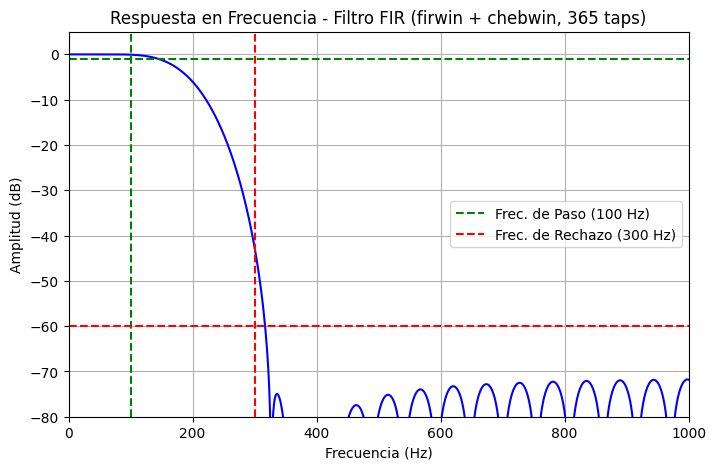

In [6]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# 1. Definir los parámetros de la plantilla
fp = 100.0      # Frecuencia de paso en Hz
f_stop = 300.0  # Frecuencia de rechazo en Hz
gpass = 1.0     # Atenuación máxima en la banda de paso (dB)
gstop = 60.0    # Atenuación mínima en la banda de rechazo (dB)

# 2. Definir la frecuencia de muestreo
# IMPORTANTE: Reemplaza 1000.0 por la frecuencia real de tu sistema
fs_muestreo = 20000.0  
nyq = 0.5 * fs_muestreo # Frecuencia de Nyquist

# 3. Calcular parámetros para firwin
# La frecuencia de corte se ubica típicamente en el centro de la banda de transición
fc = (fp + f_stop) / 2.0 

# Estimamos el número de coeficientes (taps) necesarios
ancho_transicion = (f_stop - fp) / nyq
num_taps, beta = signal.kaiserord(gstop, ancho_transicion)

# Forzamos que el número de taps sea impar (ideal para filtros FIR pasa bajos fase lineal)
if num_taps % 2 == 0:
    num_taps += 1

# 4. Diseñar el filtro usando firwin
# Usamos una ventana de Chebyshev ('chebwin') ajustada a los 60 dB de rechazo
taps_fir = signal.firwin(num_taps, fc, window=('chebwin', gstop), fs=fs_muestreo)

# --- Extra: Imprimir coeficientes listos para copiar a tu código en C ---
print(f"// Recuerda cambiar #define FIR_TAP_NUM a {num_taps} en filter.h")
print("float32_t float_fir_taps[FIR_TAP_NUM] = {")
print("    " + ", ".join([f"{t:.6f}f" for t in taps_fir]))
print("};\n")

# --- Opcional: Graficar la respuesta en frecuencia ---
w, h = signal.freqz(taps_fir, worN=8000, fs=fs_muestreo)
plt.figure(figsize=(8, 5))
plt.plot(w, 20 * np.log10(np.maximum(abs(h), 1e-5)), 'b')
plt.title(f'Respuesta en Frecuencia - Filtro FIR (firwin + chebwin, {num_taps} taps)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud (dB)')
plt.axvline(fp, color='green', linestyle='--', label='Frec. de Paso (100 Hz)')
plt.axvline(f_stop, color='red', linestyle='--', label='Frec. de Rechazo (300 Hz)')
plt.axhline(-gpass, color='green', linestyle='--')
plt.axhline(-gstop, color='red', linestyle='--')
plt.ylim(-80, 5)
plt.xlim(0, 1000)
plt.legend()
plt.grid(True)
plt.show()